In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [2]:
!pip install xgboost

In [3]:
df = pd.read_csv("/content/train[1].csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df = df.drop(columns=["Cabin"])

In [5]:
features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

In [6]:
X = pd.get_dummies(X, drop_first=True)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8100558659217877


In [9]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8212290502793296


In [10]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8044692737430168


In [11]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.810056
1,Random Forest,0.821229
2,XGBoost,0.804469


In [12]:
importance_rf = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance_rf = importance_rf.sort_values(
    by="Importance",
    ascending=False
)

importance_rf.head(10)

,Feature,Importance
5,Sex_male,0.273316
4,Fare,0.272058
1,Age,0.252745
0,Pclass,0.078616
2,SibSp,0.052192
3,Parch,0.038490
7,Embarked_S,0.023095
6,Embarked_Q,0.009488


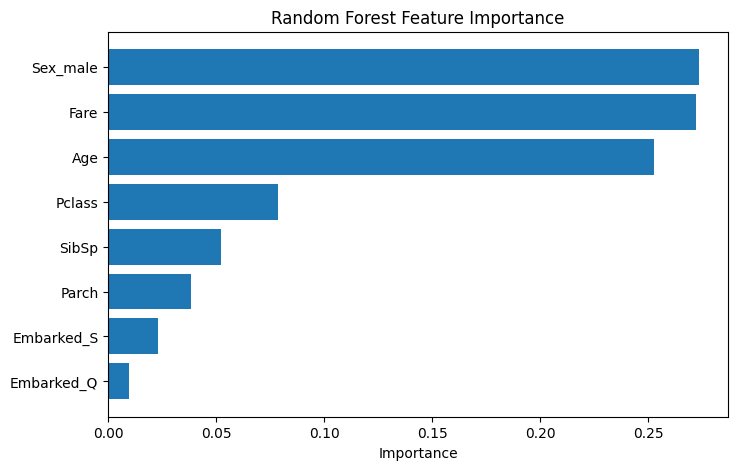

In [13]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_rf["Feature"][:10],
    importance_rf["Importance"][:10]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [14]:
importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_xgb = importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

importance_xgb.head(10)

,Feature,Importance
5,Sex_male,0.549728
0,Pclass,0.219653
2,SibSp,0.064760
7,Embarked_S,0.036934
4,Fare,0.035248
1,Age,0.033926
6,Embarked_Q,0.031558
3,Parch,0.028193


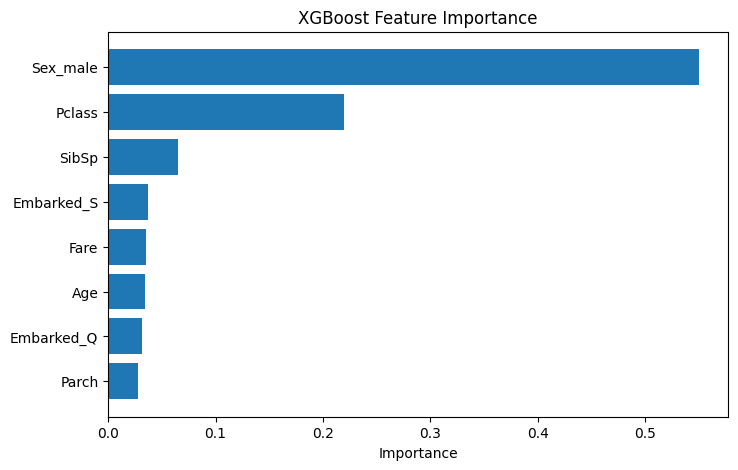

In [15]:
plt.figure(figsize=(8,5))

plt.barh(
    importance_xgb["Feature"][:10],
    importance_xgb["Importance"][:10]
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

In [16]:
print("Logistic Regression")
print(classification_report(y_test, lr_pred))

print("Random Forest")
print(classification_report(y_test, rf_pred))

print("XGBoost")
print(classification_report(y_test, xgb_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

XGBoost
              precision    recall  f1-score   support

           0       0.83      0.84      0.83       105
           1       0.77      0.76      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.80      0.8

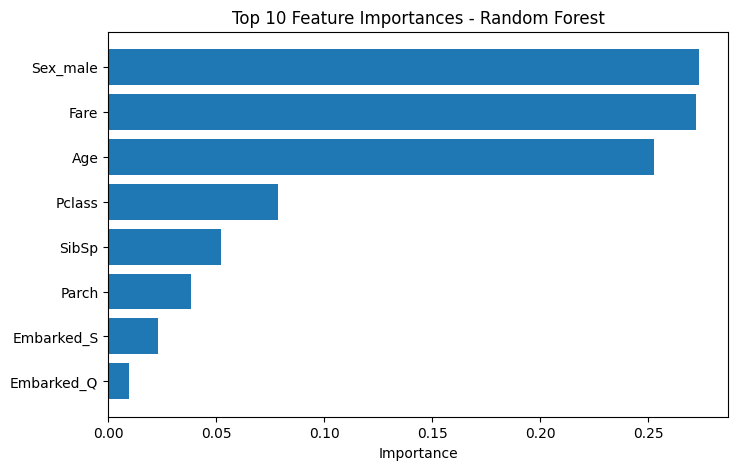

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.barh(feature_importance["Feature"][:10],
         feature_importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

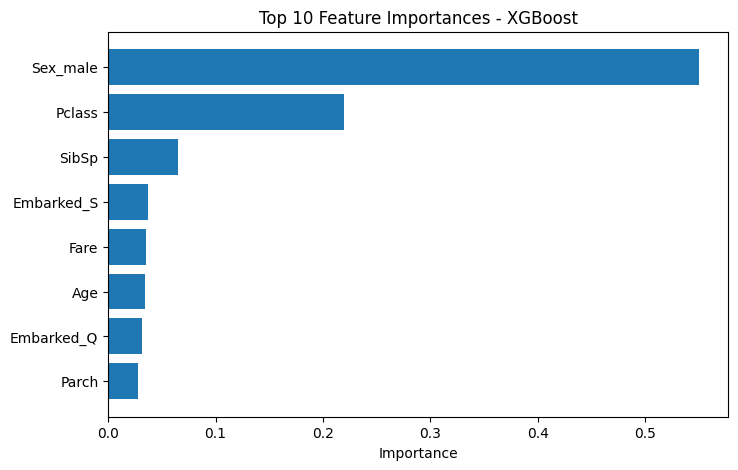

In [20]:
xgb_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))
plt.barh(xgb_importance["Feature"][:10],
         xgb_importance["Importance"][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.show()

#**Random Forest vs XGBoost**

Random Forest builds many decision trees independently and combines their predictions using voting. It reduces overfitting by averaging multiple trees. XGBoost builds trees sequentially, where each new tree focuses on correcting the mistakes made by the previous ones. In this project, Random Forest achieved the highest accuracy (82.12%), while XGBoost performed slightly lower than Logistic Regression.